In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
# Geometry objectors
from hypo.lenspy import simple_Lens 
from hypo.surface import BiconicSurface,ConicSurface
from hypo.coordinate import coord_sys
# source objector
from hypo.Feedpy import GaussiBeam

# output objector
from hypo.field_storage import Spherical_grd, plane_grd, save_grd 
from hypo.coxvec import Ludwig_Cox_vector as CO
from hypo.vecops import Vector, dot

outputdatafolder = 'Data/biconic3_si/'

In [2]:
'''1. Define coordinate system'''
coord_ref = coord_sys()
coord_feed = coord_sys(ref_coord = coord_ref)
coord_Lens1 = coord_sys(origin = [0,0,100], ref_coord= coord_ref)
coord_Lens2 = coord_sys(origin = [0,0,363], ref_coord= coord_ref)
coord_out = coord_sys(origin = [0,0,531.5], ref_coord =coord_ref)

In [3]:
'''2. Define lens two surfaces'''
r1_x =  306.8 # mm
r1_y = 236
k1_x = -11.2896
k1_y = -11.2896
Lens1_face1 = BiconicSurface(r1_x, r1_y, conic_const_x=k1_x, conic_const_y=k1_y)
r1_2 = np.inf 
Lens1_face2 = ConicSurface(r1_2)


r2_2 = np.inf 
Lens2_face1 = ConicSurface(r2_2)
r2_x = 306.8 # mm
r2_y = 377.6
k2_x = -11.2896
k2_y = -11.2896
Lens2_face2 = BiconicSurface(r2_x, r2_y, conic_const_x=k2_x, conic_const_y=k2_y)

In [4]:
'''3. Define Simple Lens'''
# refractive index
SILICON = 3.36
# thickness
t1 = 6 #mm
t2 = 6
# diameter
D  = 100# mm

Lens1 = simple_Lens(SILICON,
                    t1,
                    D,
                    Lens1_face1,
                    Lens1_face2,
                    coord_Lens1,
                    name = 'Lens1',
                    AR_file = 'AR_LIB_new/AR_perfect.h5',
                    outputfolder = outputdatafolder)


In [5]:
Lens2 = simple_Lens(SILICON,
                    t2,
                    D,
                    Lens2_face1,
                    Lens2_face2,
                    coord_Lens2,
                    name = 'Lens2',
                    AR_file = 'AR_LIB_new/AR_perfect.h5',
                    outputfolder = outputdatafolder)

In [6]:
'''4. Source: an idea Gaussian beam'''
Edge_taper  = -5.8837209 #dB
Edge_angle = 12 # degree
freq = 150
Feed = GaussiBeam(Edge_taper, Edge_angle, freq, coord_feed,polarization='x')

3.143767532927522


In [7]:
'''5. Define the fields wanted to calculated'''


Beammap = Spherical_grd(coord_ref,
                        0,0,0.8,0.8,
                        501,501,
                        Type = 'uv',
                        far_near = 'far' )

OutputBeam = plane_grd(coord_out,
                        0,0,50,50,
                        501,501)


In [8]:
''' Start PO anlaysis'''

Lens1.PO_analysis(Feed,
                  [1000,1000],
                  [1000,1000],
                  freq)




AR_LIB_new/AR_perfect.h5 150GHz
Batch size: 32
Batch size: 32


100%|██████████| 20009/20009 [22:40<00:00, 14.71it/s]


In [9]:
Lens1.surf_cur_file = outputdatafolder + 'Lens1_cur.h5'
Lens2.PO_analysis(Lens1, 
                  [1000,1000],
                  [800,800],
                  freq)

[6. 6. 6. ... 6. 6. 6.]
[4.20481065e-09 8.40962129e-09 8.40962129e-09 ... 5.82824216e-05
 5.82824216e-05 2.91412108e-05]
[263. 263. 263. ... 263. 263. 263.]
Batch size: 32
Batch size: 32


100%|██████████| 20009/20009 [22:40<00:00, 14.71it/s]


AR_LIB_new/AR_perfect.h5 150GHz
Batch size: 32
Batch size: 32


100%|██████████| 12824/12824 [14:30<00:00, 14.73it/s]


In [10]:
Lens1.source(Beammap , freq, far_near = 'far')
save_grd(Beammap, outputdatafolder+'centerbeam.h5')

Batch size: 32


100%|██████████| 7843/7843 [04:11<00:00, 31.24it/s]


In [11]:
#Lens2.surf_cur_file = outputdatafolder + 'Lens2_cur.h5'
Lens2.source(OutputBeam , freq, far_near = 'near')
save_grd(OutputBeam, outputdatafolder+'outputBW_beam.h5')

Batch size: 32
Batch size: 32


100%|██████████| 7843/7843 [05:41<00:00, 22.99it/s]


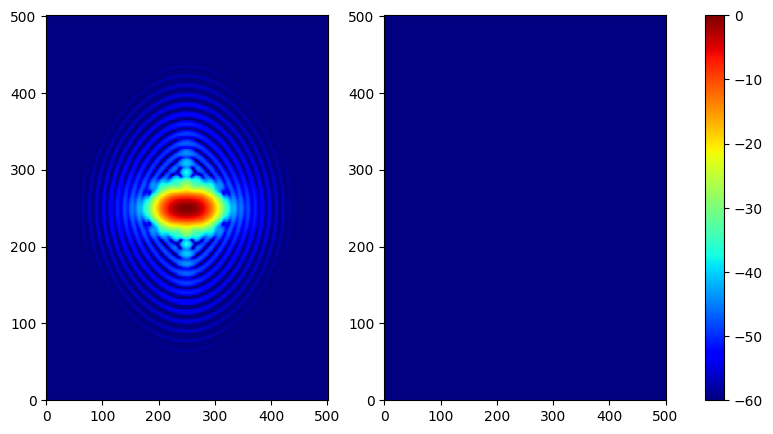

In [12]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
Max = np.abs(Beammap.E.x).max()
vmin = -60
p0 = ax[0].pcolor(np.log10(np.abs(Beammap.E.x.reshape(501,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
p1 = ax[1].pcolor(np.log10(np.abs(Beammap.E.y.reshape(501,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
cbar = fig.colorbar(p0,ax = ax.ravel())

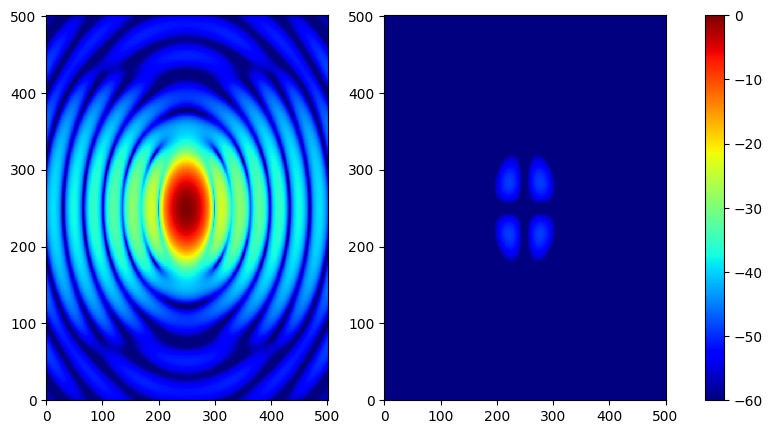

In [13]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
Max = np.abs(OutputBeam.E.x).max()
vmin = -60
p0 = ax[0].pcolor(np.log10(np.abs(OutputBeam.E.x.reshape(501,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
p1 = ax[1].pcolor(np.log10(np.abs(OutputBeam.E.y.reshape(501,-1))/Max)*20,cmap = 'jet',vmax= 0, vmin = vmin)
cbar = fig.colorbar(p0,ax = ax.ravel())

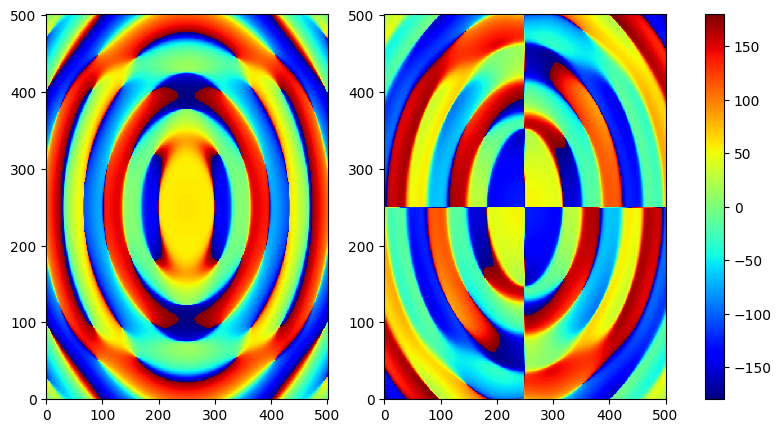

In [14]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
Max = np.abs(OutputBeam.E.x).max()
p0 = ax[0].pcolor(np.angle(OutputBeam.E.x.reshape(501,-1))*180/np.pi,cmap = 'jet',vmax= 180, vmin = -180)
p1 = ax[1].pcolor(np.angle(OutputBeam.E.y.reshape(501,-1))*180/np.pi,cmap = 'jet',vmax= 180, vmin = -180)
cbar = fig.colorbar(p0,ax = ax.ravel())